## A.3 Seeing models as computation graphs

`autograd` 是PyTorch的自动微分引擎，`autograd` 提供了函数来自动计算动态计算图。

计算图是一种有向图，可以表达和可视化数学表达式。在机器学习中，计算图规划了计算神经网络输出所需的计算序列——我们需要利用它来计算反向传播（神经网络的主要训练算法）所需的梯度。

In [1]:
import torch
import torch.nn.functional as F

[torch.nn.functional.cross_entropy](https://docs.pytorch.org/docs/stable/generated/torch.nn.functional.cross_entropy.html)

`torch.nn.functional.cross_entropy(input, target, weight=None, size_average=None, ignore_index=-100, reduce=None, reduction='mean', label_smoothing=0.0)` [source]

Compute the cross entropy loss between input logits and target.  
计算输入 logits 和目标之间的交叉熵损失。

其中 `input` 是未归一化的预测值 logits， `target` 是真实值(类别分类或类别概率)

In [2]:
# 下面实现了一个简单逻辑回归分类器的前向传播（预测步骤），它可以被视为一个单层神经网络。它返回一个 0 到 1 之间的分数，在计算损失时，该分数会与真实类别标签（0 或 1）进行比较。
y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])
z = x1 * w1 + b
a = torch.sigmoid(z) # 激活并输出
loss = F.binary_cross_entropy(a, y)
print(a, y)
print(loss)

tensor([0.9183]) tensor([1.])
tensor(0.0852)


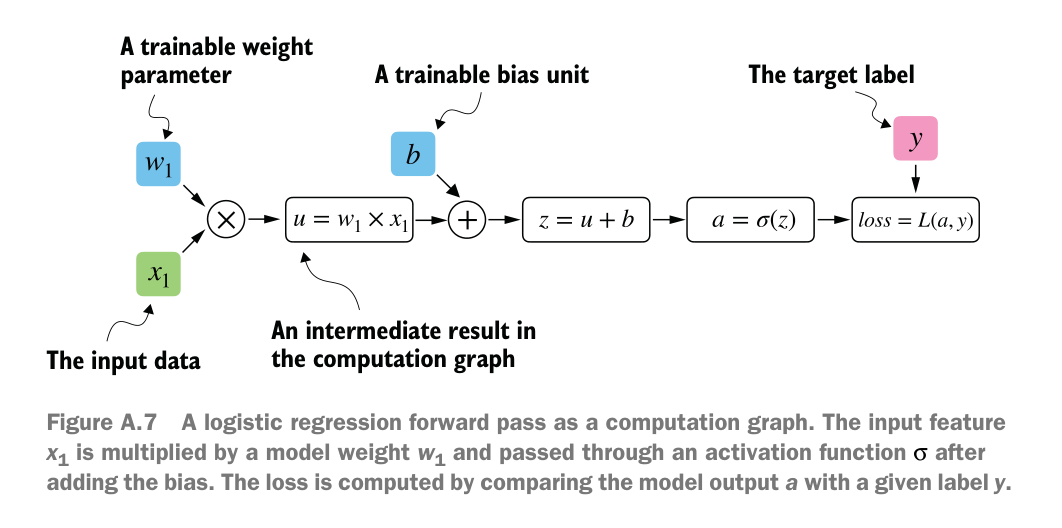

Figure A.7. 逻辑回归的前向传播计算图。输入特征 x1 乘以模型权重 w1，并在加上偏置项后通过激活函数 σ。损失值通过对比模型输出 a 与给定标签 y 来计算。

事实上，PyTorch 会在后台构建这样一个计算图，我们可以利用它来计算损失函数相对于模型参数（此处为 w1 和 b）的梯度，从而对模型进行训练。

## A.4 Automatic differentiation made easy

### 偏导数和梯度

偏导数用来衡量一个函数相对于其中一个变量的变化率。也就是在函数中保持其他自变量不变，仅对某一特定变量求导，衡量函数值随该变量变化的变化率。意义是变化率/速率。

$\frac{\partial L}{\partial \alpha}$ 可以求出 $L$ 相对于 $\alpha$ 的变化速率，由此可知怎么改变 $\alpha$ 让 $L$ 变化最大；    
$\frac{\partial \alpha}{\partial z}$ 可以求出 $\alpha$ 相对于 $z$ 的变化速率，由此可知怎么改变 $z$ 让 $\alpha$ 变化最大；    
......   
$\frac{\partial u}{\partial w_1}$ 


$$\frac{\partial L}{\partial w_1} =\frac{\partial u}{\partial w_1} \times \frac{\partial z}{\partial u} \times \frac{\partial \alpha}{\partial z} \times \frac{\partial L}{\partial \alpha}$$

由此可以知道怎么改变 $w_1$ 让 $L$ 变化最大；    


$$\frac{\partial L}{\partial b} =\frac{\partial z}{\partial b} \times \frac{\partial \alpha}{\partial z} \times \frac{\partial L}{\partial \alpha}$$

类似地，通过链式法则 chain rule 计算 $L$ 对 $b$ 的偏导数可以知道怎么改变 $b$ 让 $L$ 变化最大；   



上面的 $\frac{\partial L}{\partial w_1}，\frac{\partial L}{\partial b}，\frac{\partial u}{\partial w_1}, ... \frac{\partial z}{\partial b}, ...$等都是偏导数。但只有$\frac{\partial L}{\partial w_1}，\frac{\partial L}{\partial b}$是梯度。

本质上梯度和偏导数是一个东西。梯度是 **loss 对参数的偏导数**向量，而在神经网络中这些偏导数通常通过 chain rule（反向传播）计算得到。


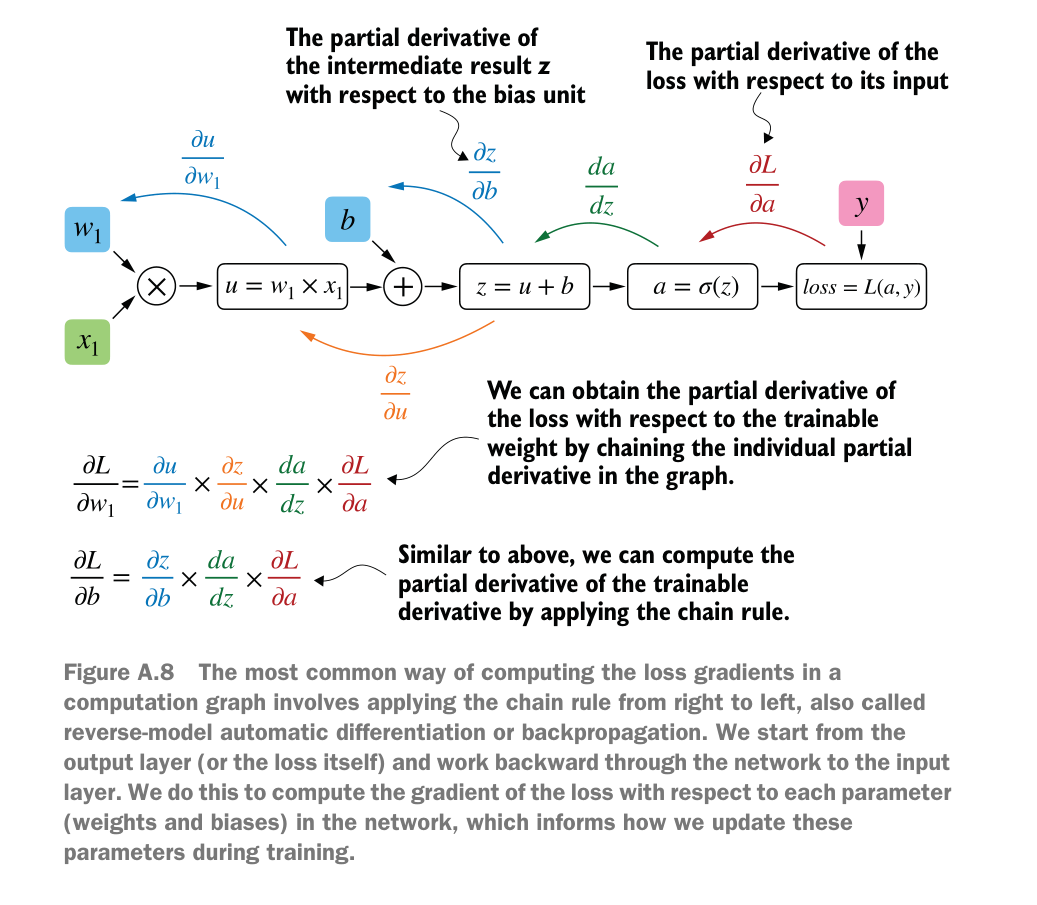

Figure A.8 在计算图中计算损失梯度最常用的方法是从右向左应用链式法则，这也称为反向模式自动微分或反向传播。我们从输出层（或损失函数本身）开始，通过网络向后推导至输入层。通过这种方式，我们可以计算出损失函数相对于网络中每个参数（权重和偏置）的梯度，从而为训练过程中如何更新这些参数提供依据。


[torch.autograd.grad](https://docs.pytorch.org/docs/stable/generated/torch.autograd.grad.html#torch-autograd-grad)

`torch.autograd.grad(outputs, inputs, grad_outputs=None, retain_graph=None, create_graph=False, only_inputs=True, allow_unused=None, is_grads_batched=False, materialize_grads=False)`       [source]

计算并且返回相对于 `inputs` 的ouput的梯度的和

`torch.autograd.grad` 计算的是 指定变量的梯度（偏导数）。也就是

$$\frac{\partial loss}{\partial w1}, \frac{\partial loss}{\partial b}$$


In [3]:
import torch
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1], requires_grad=True)
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z) # 激活
loss = F.binary_cross_entropy(a, y)
# # 默认在计算完成后会销毁计算图来释放内存，为了后面使用，这里使用 `retain_graph=True` 指定保留计算图
grad_L_w1 = grad(loss, w1, retain_graph=True)[0]  # ∂L/∂W1，L对w1的偏导数/梯度
grad_L_b = grad(loss, b, retain_graph=True)[0]  # ∂L/∂b，L对b的偏导数/梯度
# 等价于 grad_L_w1, grad_L_b = grad(loss, (w1, b), retain_graph=True)  
# grad设计可以多个输入变量同时求梯度，因此永远返回 tuple，即使只求一个


In [4]:
print(z)
print(a,y)
print(loss)
print(grad_L_w1)
print(grad_L_b)

tensor([2.4200], grad_fn=<AddBackward0>)
tensor([0.9183], grad_fn=<SigmoidBackward0>) tensor([1.])
tensor(0.0852, grad_fn=<BinaryCrossEntropyBackward0>)
tensor([-0.0898])
tensor([-0.0817])


### Pytorch求梯度 `grad` 和 `.backward()` 的区别

`.backward()`

如：`loss.backward()`

* 计算所有参数梯度  
* 写入对应变量的 .grad  
* 用于训练  

`torch.autograd.grad`

如： `grad(loss, w1)`

* 只计算你指定变量  
* 不会写入 .grad  
* 直接返回梯度值  

常用于：  
* 手动求导  
* 分析计算图  
* 高阶梯度  
* meta-learning   

In [5]:
loss.backward()
print(w1.grad)
print(b.grad)

tensor([-0.0898])
tensor([-0.0817])


forward pass  → 计算 loss

backward pass → 求 loss 对参数的导数

$$gradient=“如果参数变一点，loss 会变多少？”$$

### 手动求梯度 Vs. 自动求梯度


`z = x1 * w1 + b`   
`a = sigmoid(z)` = $\frac{1}{1+ e^{-z}}$   
`L = (a - y)^2` = $(a - y)^2$


#### Step 1：逐层求导

① loss 对 a

$$L = (a - y)^2$$

$$\frac{\partial L}{\partial a} = 2(a - y)$$

② sigmoid 导数

$$
a = \sigma(z) = \frac{1}{1+ e^{-z}}
$$

$$
\frac{\partial a}{\partial z} = a(1-a)
$$

③ z 对 w1

$$
z = x1 * w1 + b
$$

$$
\frac{\partial z}{\partial w_1} = x_1
$$

$$
\frac{\partial z}{\partial b} = 1
$$


#### Step 2：chain rule 合并

$$
\frac{\partial L}{\partial w_1} =

\frac{\partial L}{\partial a} \times
\frac{\partial a}{\partial z} \times
\frac{\partial z}{\partial w_1}
$$

类似地，

$$
\frac{\partial L}{\partial b} =

\frac{\partial L}{\partial a} \times
\frac{\partial a}{\partial z} \times
\frac{\partial z}{\partial b}
$$


In [6]:
import torch
import torch.nn.functional as F
from torch.autograd import grad

y = torch.tensor([1.0])
x1 = torch.tensor([1.1], requires_grad=True)
w1 = torch.tensor([2.2], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

z = x1 * w1 + b
a = torch.sigmoid(z) # 激活
loss = (a - y)**2
# # 默认在计算完成后会销毁计算图来释放内存，为了后面使用，这里使用 `retain_graph=True` 指定保留计算图
grad_L_w1 = grad(loss, w1, retain_graph=True)[0]  # ∂L/∂W1，L对w1的偏导数/梯度
grad_L_b = grad(loss, b, retain_graph=True)[0]  # ∂L/∂b，L对b的偏导数/梯度


In [7]:
print(L)
print(grad_L_w1)
print(grad_L_b)

NameError: name 'L' is not defined

In [ ]:
def sigmoid(z):
    return 1.0 / (1 + torch.exp(-z))

def loss(a, y):
    return (a - y)**2

y = torch.tensor([1.0])
x1 = torch.tensor([1.1])
w1 = torch.tensor([2.2])
b = torch.tensor([0.0])
z = x1 * w1 + b
a= sigmoid(z)
L = loss(a, y)
print(L)
# 虽然autograd.grad只是局部需要计算图，但仍然依赖它，需要y, x1等设置 requires_grad=True
# torch.autograd.grad(L, w1)

tensor([0.0067])


In [ ]:
# L 对 a 求导  L = a^2 - 2*a*y + y^2, 导数 L' = 2*a -2y
dL_da = 2 * (a-y)
# a 对 z 求导   a = 1.0 / (1 + torch.exp(-z)), 导数 a' = a(1−a)
da_dz = a * (1-a)
# z 对 w 求导   z = x1 * w1 + b，导数 z' = x1
dz_dw1 = x1
# z 对 b 求导   z = x1 * w1 + b
dz_db = torch.tensor([1.])
print(f"dL_da = {dL_da.item()}, da_dz = {da_dz.item()}, dz_dw1 = {dz_dw1.item()}, dz_db = {dz_db.item()}")

# 利用 chain rule 计算 dL_dw1
dL_dw1 = dz_dw1 * da_dz * dL_da
# 利用 chain rule 计算 dL_db
dL_db = dz_db * da_dz * dL_da

print(f"dL_dw1 = {dL_dw1}, dL_db = {dL_db}")
print(grad_L_w1 == dL_dw1)
print(grad_L_b == dL_db)

dL_da = -0.16332054138183594, da_dz = 0.074991874396801, dz_dw1 = 1.100000023841858, dz_db = 1.0
dL_dw1 = tensor([-0.0135]), dL_db = tensor([-0.0122])
tensor([True])
tensor([True])


### 前向传播和反向传播

**前向传播** = 函数值的计算过程（function evaluation）， 把输入参数“变成”输出 loss

比如 从 w1, x1, b 一步一步计算得到 loss

$$w_1, x_1, b
\rightarrow z = w_1 x_1 + b
\rightarrow a = \sigma(z)
\rightarrow L = L(a, y) 
$$


**反向传播** = 利用链式法则计算梯度的过程，用链式法则，把梯度从 loss 往回传递

$$L \rightarrow a \rightarrow z \rightarrow w,b$$



$$
\frac{\partial L}{\partial a}
\rightarrow
\frac{\partial a}{\partial z} 
\rightarrow
\frac{\partial z}{\partial w_1}
\rightarrow
\frac{\partial L}{\partial w_1}, \frac{\partial L}{\partial b} 
$$

$$
\frac{\partial L}{\partial w_1} =
\frac{\partial L}{\partial a} \times
\frac{\partial a}{\partial z} \times
\frac{\partial z}{\partial w_1}
$$

类似地，

$$
\frac{\partial L}{\partial b} =

\frac{\partial L}{\partial a} \times
\frac{\partial a}{\partial z} \times
\frac{\partial z}{\partial b}
$$




| 过程   | 做什么     | 方向             |
| ---- | ------- | -------------- |
| 前向传播 | 计算 loss | input → output |
| 反向传播 | 计算梯度    | output → input |



### 得到 gradient 后怎么进行优化？

类比你在下山：

* 梯度 = 哪个方向最陡
* learning rate = 你每一步跨多大

#### 梯度 gradient

梯度 = 参数对 loss 变化率的影响：  
* 梯度的符号说明参数变化对Loss的影响是正向还是反向；  
  * 正值 → 参数变大，loss 变大  
  * 负值 → 参数变大，loss 变小
* 梯度的大小说明它对loss变化的影响大还是小。 


|    | $\frac{\partial L}{\partial w_1} > 0$      | $\frac{\partial L}{\partial w_1} < 0$    |
| ---- | ------- | -------------- |
| $Loss > 0$ | $\uparrow$  | $\downarrow$ |
| $Loss < 0$ | $\downarrow$ | $\uparrow$ |

#### 学习率 learning rate

learning rate（$η$）= 每次更新参数“走多远”的步长系数

每次按以下方式更新$w$

$$w \leftarrow w - \eta \cdot \nabla L$$


举例 $L(w) = (w - 3)^2$ 

目标：让 L 最小（显然最优解是 w = 3）


1. Step 1：求梯度 $\frac{dL}{dw} = 2(w - 3)$

假设初始值 $w = 0$,   

梯度 $\frac{dL}{dw} = 2(0 - 3) = -6$

2. Step 2: 更新w

$$w \leftarrow w - \eta \cdot \nabla L$$

1. learning rate = 1(太大)， 带入得 $w = 0 - 1 \cdot (-6) = 6, L(w) = 9$, 还是9;   
2. learning rate = 0.5（合理）, 带入得 $w = 0 - 0.5 \cdot (-6) = 3, L(w) = 0$，从 9 变成 0，一步到最优点（刚好这个函数太简单）；  
3. learning rate = 0.1（更现实），带入得 $w = 0 - 0.1 \cdot (-6) = 0.6, L(w) = 5.76$， 从 9 变成 5.76；
   1. 下一步再优化 $w = 0.6 - 0.1(-4.8) = 1.08， L(w) = 3.69$

w 在最后$η=0.1$的例子中一步步逼近最优解3， 同时$L(w)$也逼近最优的0

```
0 → 0.6 → 1.08 → 1.75 → 2.25 → 2.7 → 3
```

* $η$ 太大 → 一步跨过最优点 → 来回震荡 / 发散
* $η$ 太小 → 走得太慢 → 训练非常慢


## A.5 Implementing multilayer neural networks

In [ ]:
import torch
import torch.nn as nn

In [ ]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_inputs, num_outputs): # 分别指输入和输出数据的维度
        super().__init__()
        
        self.layers = nn.Sequential(
            nn.Linear(num_inputs, 30),  # 线性层取输入和输出节点的数量作为参数
            nn.ReLU(),                  # 在隐藏层之间使用非线性的激活函数
            
            nn.Linear(30, 20),          # 输入输出参数要分别和上一次输出和下一次输入相匹配
            nn.ReLU(),
            
            nn.Linear(20, num_outputs)
        )
    
    def forward(self, x):
        # 最终output layer 的输出一般称作 logits
        # Logits是神经网络最终层在通过softmax或sigmoid等激活函数之前产生的原始、未经归一化的输出分数。
        logits = self.layers(x) 
        return logits

In [ ]:
torch.manual_seed(123)
model = NeuralNetwork(50, 3)
print(model)

NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)


```parameters(recurse=True)```

[nn.Module.parameters()](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.parameters)

返回模块参数的迭代器。

这通常传递给一个优化器。

**参数Parameters**：   
    **recurse** (bool) – if True, then yields parameters of this module and all submodules. Otherwise, yields only parameters that are direct members of this module. 是的话返回本模块和所有子模块涉及autograd的参数，否则只返回本模块的参数

**返回类型Return type**:  
    Iterator[Parameter]

```
for param in model.parameters():  
      print(type(param), param.size())  
```
```
<class 'torch.Tensor'> (20L,)  
<class 'torch.Tensor'> (20L, 1L, 5L, 5L)
```


[Understanding nn.Module.parameters()  理解nn.Module.parameters()方法](https://discuss.pytorch.org/t/understanding-nn-module-parameters/94887)

```torch.numel(input: Tensor) → int```

[torch.numel](https://docs.pytorch.org/docs/stable/generated/torch.numel.html)

`numel` (short for number of elements) 返回在 `input` 这个tensor中元素的总数

```
a = torch.randn(1, 2, 3, 4, 5)
torch.numel(a)
120
a = torch.zeros(4,4)
torch.numel(a)
16
```

In [ ]:
lst = [p for p in model.parameters() if p.requires_grad]
# print(lst) # 输出所有参数
print(lst[0]) # 第一层w
print(lst[0].numel())
print(lst[1]) # 第一层b
print(lst[1].numel())
print(sum(x.numel() for x in lst))

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)
1500
Parameter containing:
tensor([-0.1250,  0.0513,  0.0366,  0.0075,  0.0509,  0.0545, -0.0393,  0.0924,
        -0.1412, -0.1232, -0.1063,  0.0081, -0.1249,  0.0101, -0.0019, -0.1298,
         0.1388, -0.0330,  0.1017,  0.1247, -0.0554, -0.0417,  0.1388,  0.0159,
         0.1215,  0.0385,  0.0769, -0.1224, -0.0279,  0.0991],
       requires_grad=True)
30
2213


In [ ]:
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)

Total number of trainable model parameters: 2213


```
NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=50, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=3, bias=True)
  )
)
```

|层数|w.shape|b.shape|总计|
|---|---|---|---|
|第一层| w[50*30] |bias[30]|1500+30=1530|
|第二层| w[30*20] |bias[20]|600+20=620|
|第三层| w[20*3] |bias[3]|60+3=63|
|总计| | | 2213|

In [ ]:
print(model.layers[0].weight)

Parameter containing:
tensor([[-0.0577,  0.0047, -0.0702,  ...,  0.0222,  0.1260,  0.0865],
        [ 0.0502,  0.0307,  0.0333,  ...,  0.0951,  0.1134, -0.0297],
        [ 0.1077, -0.1108,  0.0122,  ...,  0.0108, -0.1049, -0.1063],
        ...,
        [-0.0787,  0.1259,  0.0803,  ...,  0.1218,  0.1303, -0.1351],
        [ 0.1359,  0.0175, -0.0673,  ...,  0.0674,  0.0676,  0.1058],
        [ 0.0790,  0.1343, -0.0293,  ...,  0.0344, -0.0971, -0.0509]],
       requires_grad=True)


In [ ]:
print(model.layers[0].weight.shape)
print(model.layers[0].bias.shape)

torch.Size([30, 50])
torch.Size([30])


In [ ]:
torch.manual_seed(123)
x = torch.rand((1,50))
out = model(x)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]], grad_fn=<AddmmBackward0>)


In [ ]:
with torch.no_grad():   # 指定Pytorch不需要跟踪梯度，节省内存和计算
    out = model(x)
print(out)

tensor([[-0.1262,  0.1080, -0.1792]])


### 为什么最后一层不需要非线性激活函数？

按照一般的流程是手动归一化：

> logits → softmax/sigmoid → cross entropy

但 PyTorch 实际是：

> logits → CrossEntropyLoss（内部做 softmax + NLL）


也就是说：

👉 softmax 被“藏进 loss 里了”

第一个原因：   

目的是为了 **数值稳定性（numerical stability）**

因为自己手动做softmax容易导致指数爆炸，而pytorch的CrossEntropyLoss内部做了处理优化，可以计算更稳定

第二个原因：

最后一层的作用不是“变非线性”，而是： **输出一个“分数向量”，交给 loss 去解释**

但是训练时不一定需要这个解释，训练过程主要需要loss来学习，因此Pytorch让 loss 直接处理 logits（更稳定 + 更高效）

| 部分      | 作用                |
| ------- | ----------------- |
| logits  | 模型“打分”            |
| softmax | 把分数变概率            |
| loss    | 负责“判断好坏 + 提供学习信号” |



In [ ]:
with torch.no_grad():
    out = torch.softmax(model(x), dim=-1)
print(out)
# 输出可以被理解为 out_dim=3 个分类各自的概率。因为是随机输入，所以概率接近

tensor([[0.3113, 0.3934, 0.2952]])
